In [1]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Embedding(input_dim=10000, output_dim=32, input_length=150),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_features = 10000
maxlen = 150

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

x_train_small = x_train[:100]
y_train_small = y_train[:100]

In [5]:
history = model.fit(
    x_train_small,
    y_train_small,
    epochs=10,
    batch_size=16,
    validation_data=(x_test[:10000], y_test[:10000])
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 386ms/step - accuracy: 0.5700 - loss: 0.6921 - val_accuracy: 0.5126 - val_loss: 0.6929
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - accuracy: 0.5900 - loss: 0.6883 - val_accuracy: 0.5090 - val_loss: 0.6928
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.5600 - loss: 0.6849 - val_accuracy: 0.5106 - val_loss: 0.6926
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.5900 - loss: 0.6801 - val_accuracy: 0.5147 - val_loss: 0.6923
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - accuracy: 0.6100 - loss: 0.6755 - val_accuracy: 0.5164 - val_loss: 0.6920
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - accuracy: 0.6200 - loss: 0.6698 - val_accuracy: 0.5169 - val_loss: 0.6915
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 294ms/step - accuracy: 0.6300 - loss: 0.6628 - val_accuracy: 0.5189 - val_loss: 0.6909
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step - accuracy: 0.6400 - loss: 0.6549 - val_accuracy: 0.5210 - val_loss:

In [6]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2026-04-18 02:30:12--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-04-18 02:30:12--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-04-18 02:30:12--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [7]:
import numpy as np

embedding_index = {}

with open("glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

print("Loaded %s word vectors." % len(embedding_index))

Loaded 400000 word vectors.


In [8]:
word_index = imdb.get_word_index()

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
embedding_dim = 100

embedding_matrix = np.zeros((10000, embedding_dim))

for word, i in word_index.items():
    if i < 10000:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

In [11]:
from tensorflow import keras
from tensorflow.keras import layers

model_glove = keras.Sequential([
    layers.Embedding(
        input_dim=10000,
        output_dim=100,  # embedding_dim = 100
        weights=[embedding_matrix],
        input_length=150,
        trainable=False
    ),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_glove.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_glove.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [12]:
history_glove = model_glove.fit(
    x_train_small,
    y_train_small,
    epochs=10,
    batch_size=16,
    validation_data=(x_test[:10000], y_test[:10000])
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 451ms/step - accuracy: 0.4200 - loss: 0.7610 - val_accuracy: 0.4943 - val_loss: 0.6973
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step - accuracy: 0.5600 - loss: 0.6899 - val_accuracy: 0.5027 - val_loss: 0.7019
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - accuracy: 0.5800 - loss: 0.6811 - val_accuracy: 0.5027 - val_loss: 0.7200
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - accuracy: 0.5800 - loss: 0.6800 - val_accuracy: 0.5027 - val_loss: 0.7152
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.5800 - loss: 0.6787 - val_accuracy: 0.5027 - val_loss: 0.7125
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - accuracy: 0.5800 - loss: 0.6777 - val_accuracy: 0.5027 - val_loss: 0.7137
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.5800 - loss: 0.6771 - val_accuracy: 0.5027 - val_loss: 0.7112
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step - accuracy: 0.5800 - loss: 0.6774 - val_accuracy: 0.5027 - val_loss:

In [13]:
x_train_500 = x_train[:500]
y_train_500 = y_train[:500]

In [14]:
model_500 = keras.Sequential([
    layers.Embedding(input_dim=10000, output_dim=32, input_length=150),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_500.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_500 = model_500.fit(
    x_train_500,
    y_train_500,
    epochs=10,
    batch_size=16,
    validation_data=(x_test[:10000], y_test[:10000])
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.5280 - loss: 0.6926 - val_accuracy: 0.5321 - val_loss: 0.6915
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.7040 - loss: 0.6865 - val_accuracy: 0.5995 - val_loss: 0.6875
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.8140 - loss: 0.6725 - val_accuracy: 0.6473 - val_loss: 0.6784
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8200 - loss: 0.6433 - val_accuracy: 0.6855 - val_loss: 0.6626
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.8840 - loss: 0.5910 - val_accuracy: 0.7211 - val_loss: 0.6304
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9180 - loss: 0.5152 - val_accuracy: 0.7406 - val_loss: 0.5944
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9420 - loss: 0.4183 - val_accuracy: 0.7637 - val_loss: 0.5539
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9600 - loss: 0.3336 - val_accuracy: 0.7495 - v

In [15]:
history_glove_500 = model_glove.fit(
    x_train_500,
    y_train_500,
    epochs=10,
    batch_size=16,
    validation_data=(x_test[:10000], y_test[:10000])
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.5240 - loss: 0.6946 - val_accuracy: 0.4898 - val_loss: 0.6946
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5040 - loss: 0.6942 - val_accuracy: 0.4949 - val_loss: 0.6936
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5000 - loss: 0.6935 - val_accuracy: 0.5123 - val_loss: 0.6929
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5400 - loss: 0.6916 - val_accuracy: 0.5060 - val_loss: 0.6929
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5400 - loss: 0.6916 - val_accuracy: 0.5178 - val_loss: 0.6921
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.5340 - loss: 0.6915 - val_accuracy: 0.5209 - val_loss: 0.6918
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.5640 - loss: 0.6891 - val_accuracy: 0.5241 - val_loss: 0.6914
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5660 - loss: 0.6887 - val_accuracy: 0.5346 - v

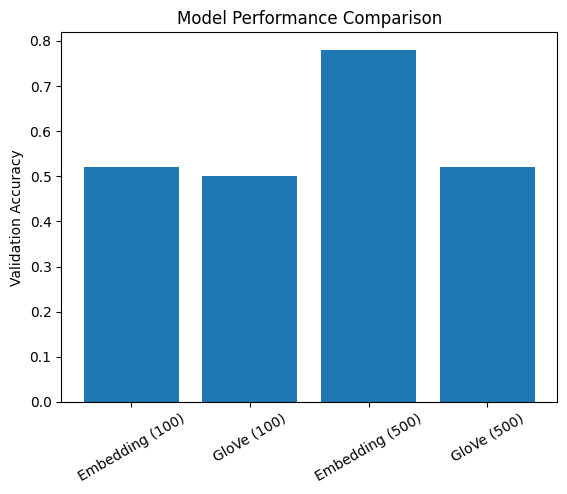

In [17]:
import matplotlib.pyplot as plt

labels = ['Embedding (100)', 'GloVe (100)', 'Embedding (500)', 'GloVe (500)']
values = [0.52, 0.50, 0.78, 0.52]

plt.figure()
plt.bar(labels, values)
plt.title("Model Performance Comparison")
plt.ylabel("Validation Accuracy")
plt.xticks(rotation=30)
plt.show()